# FoodSure AI — Baseline Classification Models

## AI-Based Turmeric Adulteration Detection & Quantification

This notebook establishes baseline machine-learning models for multiclass
classification of turmeric adulteration levels.

### Classification Classes

The model predicts one of the following adulteration levels:

- 0%
- 1%
- 2%
- 3%
- 5%
- 7%
- 9%

### Modalities

Baseline experiments are performed separately on:

1. Color measurements
2. FTIR spectroscopy
3. EfficientNet-B0 image features

### Baseline Models

The initial models are:

- Logistic Regression
- Support Vector Machine (SVM)
- Random Forest

### Objectives

The main objectives are:

- establish reproducible baseline performance
- compare different machine-learning algorithms
- compare the predictive information available in each modality
- identify which approaches should be investigated further
- provide reference results for later advanced models and multimodal fusion

### Evaluation

The models will be evaluated using:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1-score
- Confusion Matrix

The same fixed train/test split created during preprocessing will be used
throughout the experiments.

> Important:
> The test set is kept fixed and is not used for model tuning.
> All preprocessing transformations were fitted using training data only.

In [264]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## 2. Load Preprocessed Data

The preprocessing notebook created leakage-safe train/test datasets.

We reuse those datasets instead of creating a new split.

This ensures that all baseline models are evaluated on exactly the same
training and testing samples.

In [265]:
preprocessed_dir = "../preprocessed"

# Target
y_train = pd.read_csv(
    os.path.join(preprocessed_dir, "y_train.csv")
).squeeze()

y_test = pd.read_csv(
    os.path.join(preprocessed_dir, "y_test.csv")
).squeeze()

# Color
X_color_train = pd.read_csv(
    os.path.join(preprocessed_dir, "X_color_train_pca.csv")
)
X_color_test = pd.read_csv(
    os.path.join(preprocessed_dir, "X_color_test_pca.csv")
)

# FTIR
X_ftir_train = pd.read_csv(
    os.path.join(preprocessed_dir, "X_ftir_train_pca.csv")
)
X_ftir_test = pd.read_csv(
    os.path.join(preprocessed_dir, "X_ftir_test_pca.csv")
)

# Image
X_image_train = pd.read_csv(
    os.path.join(preprocessed_dir, "X_image_train_pca.csv")
)
X_image_test = pd.read_csv(
    os.path.join(preprocessed_dir, "X_image_test_pca.csv")
)

print("Color:", X_color_train.shape, X_color_test.shape)
print("FTIR:", X_ftir_train.shape, X_ftir_test.shape)
print("Image:", X_image_train.shape, X_image_test.shape)
print("y:", y_train.shape, y_test.shape)

Color: (280, 3) (70, 3)
FTIR: (280, 91) (70, 91)
Image: (280, 48) (70, 48)
y: (280,) (70,)


## 3. Verify Train/Test Data

Before training the baseline models, we verify:

- the target classes present in the dataset
- the number of samples in each class
- the training and testing distributions
- that no unexpected target values are present

The dataset contains seven adulteration levels:

0%, 1%, 2%, 3%, 5%, 7%, and 9%.

In [266]:
print("Training classes:")
print(sorted(y_train.unique()))

print("\nTesting classes:")
print(sorted(y_test.unique()))

Training classes:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(5.0), np.float64(7.0), np.float64(9.0)]

Testing classes:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(5.0), np.float64(7.0), np.float64(9.0)]


3.2 — Check Class Distribution

In [267]:
train_distribution = y_train.value_counts().sort_index()
test_distribution = y_test.value_counts().sort_index()

distribution_table = pd.DataFrame({
    "Training Samples": train_distribution,
    "Testing Samples": test_distribution
})

distribution_table

,Training Samples,Testing Samples
Adulteration_Percent,,
0.0,40,10
1.0,40,10
2.0,40,10
3.0,40,10
5.0,40,10
7.0,40,10
9.0,40,10


### Class Distribution Visualization

A bar chart is used to visually confirm that each adulteration level
contains the same number of training and testing samples.

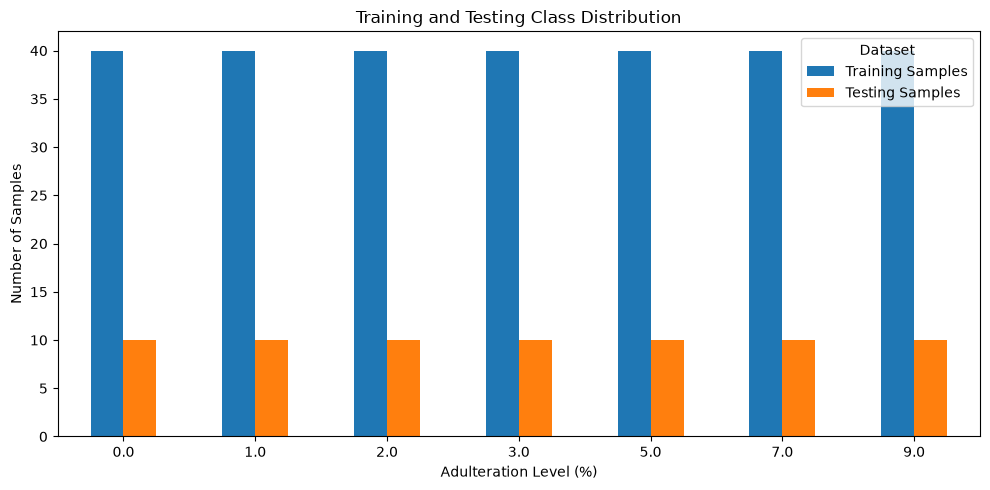

In [268]:
distribution_table.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Training and Testing Class Distribution")
plt.xlabel("Adulteration Level (%)")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

“The dataset was divided into a stratified train-test split, resulting in 40 training samples and 10 testing samples for each adulteration level. Therefore, all seven classes have equal representation in both sets, reducing the effect of class imbalance on model evaluation.”

-----------------------------------------------------------------------------

## 4. Color Baseline — Logistic Regression

Logistic Regression is used as the first baseline classifier.

It provides a simple reference point for determining whether the
color-based features contain useful information for distinguishing
different turmeric adulteration levels.

The model performs multiclass classification across seven classes:

0%, 1%, 2%, 3%, 5%, 7%, and 9%.

The model is trained only on the training data and evaluated on the
fixed test set.

In [269]:
color_lr = LogisticRegression(#algorithm that models the probability of discrete class outcomes.
    max_iter=2000, #Increases the maximum number of iterations allowed for the optimization solver to converge
    #Setting it higher ensures the algorithm has enough steps to find the optimal weights.
    random_state=42
)

color_lr.fit(X_color_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [270]:
y_color_lr_pred = color_lr.predict(X_color_test)
#Uses your trained Logistic Regression model (color_lr) to predict the adulteration levels for the unseen test dataset (X_color_test).

print("Predictions generated successfully.")
print("Number of predictions:", len(y_color_lr_pred))

Predictions generated successfully.
Number of predictions: 70


In [271]:
color_lr_accuracy = accuracy_score(y_test, y_color_lr_pred)

color_lr_precision = precision_score(
    y_test,
    y_color_lr_pred,
    average="macro",
    zero_division=0 #Prevents the code from throwing an error if a class receives zero predicted positive samples.
)

color_lr_recall = recall_score(
    y_test,
    y_color_lr_pred,
    average="macro",
    zero_division=0
)

color_lr_f1 = f1_score( #Calculates the harmonic mean of precision and recall for each class, then computes the macro average across all classes:
    y_test,
    y_color_lr_pred,
    average="macro", #Why average="macro"?
#Because your dataset has 7 distinct adulteration levels (0%, 1%, 2%, 3%, 5%, 7%, and 9%), macro-averaging ensures that every class is treated with equal importance regardless of minor variations, giving an unbiased picture of performance across all adulteration thresholds.
    zero_division=0
)

print(f"Accuracy       : {color_lr_accuracy:.4f}")
print(f"Macro Precision: {color_lr_precision:.4f}")
print(f"Macro Recall   : {color_lr_recall:.4f}")
print(f"Macro F1       : {color_lr_f1:.4f}")

Accuracy       : 0.8714
Macro Precision: 0.8740
Macro Recall   : 0.8714
Macro F1       : 0.8684


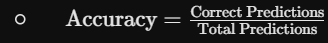

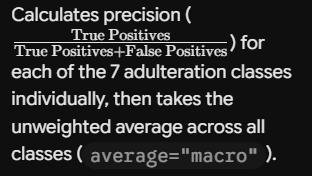

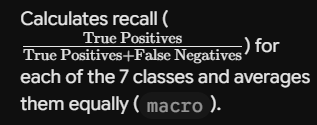

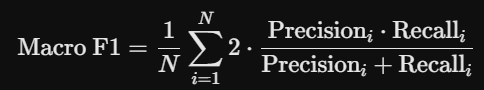

### Interpretation

The Color + Logistic Regression baseline achieved:

- Accuracy: 87.14%
- Macro Precision: 87.40%
- Macro Recall: 87.14%
- Macro F1-score: 86.84%

The results indicate that the color-based representation contains
useful information for distinguishing the seven turmeric adulteration
levels in this dataset.

The relatively similar macro precision, recall, and F1-score suggest
that the model's performance is not determined solely by one or a
small number of classes.

However, this result is only a baseline and does not establish that
color measurements are the most informative modality. Further
experiments using FTIR spectroscopy, image features, SVM, Random
Forest, and multimodal approaches are required.

The evaluation was performed on the fixed test set that was separated
before model training.

-------------------------------------------------------

## 4.1 Confusion Matrix

A confusion matrix shows the relationship between the actual
adulteration level and the level predicted by the model.

The diagonal cells represent correctly classified samples, while
off-diagonal cells represent classification errors.

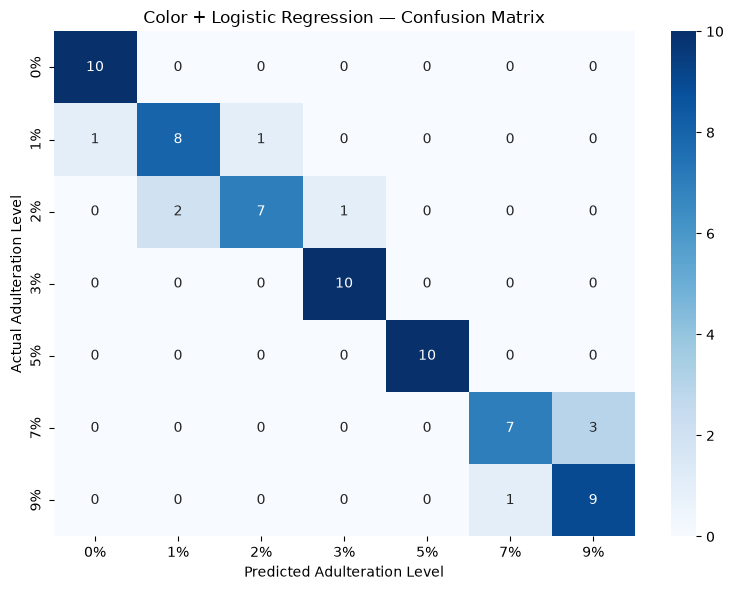

In [272]:
cm_color_lr = confusion_matrix(
    y_test,
    y_color_lr_pred,
    labels=[0, 1, 2, 3, 5, 7, 9]
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_color_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["0%", "1%", "2%", "3%", "5%", "7%", "9%"],
    yticklabels=["0%", "1%", "2%", "3%", "5%", "7%", "9%"]
)

plt.xlabel("Predicted Adulteration Level")
plt.ylabel("Actual Adulteration Level")
plt.title("Color + Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

🔎 Main observations

0%, 3%, and 5%

All 10/10 correctly classified.
These classes show no errors on this test split.

1%

8/10 correctly classified.
1 sample predicted as 0%.
1 sample predicted as 2%.

2%

7/10 correctly classified.
2 predicted as 1%.
1 predicted as 3%.

7%

7/10 correctly classified.
3 predicted as 9%.

9%

9/10 correctly classified.
1 predicted as 7%.
🧠 Interesting pattern

Most mistakes occur between nearby adulteration levels:

0% ↔ 1% ↔ 2% ↔ 3%

7% ↔ 9%

while the model doesn't appear to confuse these classes with much more distant levels such as 0% vs 9%.

-----------------------------------------------------------------------------

## 4.2 Classification Report

The classification report provides precision, recall, and F1-score
for each individual adulteration class.

In [273]:
print(
    classification_report(
        y_test,
        y_color_lr_pred,
        labels=[0, 1, 2, 3, 5, 7, 9],
        target_names=["0%", "1%", "2%", "3%", "5%", "7%", "9%"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

          0%       0.91      1.00      0.95        10
          1%       0.80      0.80      0.80        10
          2%       0.88      0.70      0.78        10
          3%       0.91      1.00      0.95        10
          5%       1.00      1.00      1.00        10
          7%       0.88      0.70      0.78        10
          9%       0.75      0.90      0.82        10

    accuracy                           0.87        70
   macro avg       0.87      0.87      0.87        70
weighted avg       0.87      0.87      0.87        70



### Per-Class Interpretation

The classification report shows variation in performance across the
seven adulteration levels.

The 5% class achieved an F1-score of 1.00 on the test set, while the
0% and 3% classes achieved F1-scores of 0.95.

The 2% and 7% classes had the lowest recall values at 0.70. The
confusion matrix indicates that 2% samples were mainly confused with
1% and 3%, while 7% samples were mainly confused with 9%.

The 9% class achieved a recall of 0.90 but a lower precision of 0.75,
indicating that some samples predicted as 9% actually belonged to
another class.

These results describe performance on the fixed 70-sample test set
and should not be interpreted as evidence that the same performance
will necessarily occur on new physical samples.

## 4.3 Baseline Result

The Color + Logistic Regression result is stored so that it can be
compared with the other baseline models.

In [274]:
baseline_results = []

baseline_results.append({
    "Modality": "Color",
    "Model": "Logistic Regression",
    "Accuracy": color_lr_accuracy,
    "Macro Precision": color_lr_precision,
    "Macro Recall": color_lr_recall,
    "Macro F1": color_lr_f1
})

baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df

,Modality,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Color,Logistic Regression,0.871429,0.874026,0.871429,0.868357


-----------------------------------------------------------------------------

## 5. Color Baseline — Support Vector Machine

A Support Vector Machine (SVM) is evaluated as a second baseline
classifier for the color modality.

An RBF kernel is used to allow nonlinear decision boundaries between
the adulteration classes.

The model is trained using the same fixed training set and evaluated
on the same fixed test set as the Logistic Regression baseline.

In [275]:
color_svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

color_svm.fit(X_color_train, y_train)

y_color_svm_pred = color_svm.predict(X_color_test)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_color_svm_pred))

Predictions generated successfully.
Number of predictions: 70


In [276]:
color_svm_accuracy = accuracy_score(
    y_test,
    y_color_svm_pred
)

color_svm_precision = precision_score(
    y_test,
    y_color_svm_pred,
    average="macro",
    zero_division=0
)

color_svm_recall = recall_score(
    y_test,
    y_color_svm_pred,
    average="macro",
    zero_division=0
)

color_svm_f1 = f1_score(
    y_test,
    y_color_svm_pred,
    average="macro",
    zero_division=0
)

print(f"Accuracy       : {color_svm_accuracy:.4f}")
print(f"Macro Precision: {color_svm_precision:.4f}")
print(f"Macro Recall   : {color_svm_recall:.4f}")
print(f"Macro F1       : {color_svm_f1:.4f}")

Accuracy       : 0.8857
Macro Precision: 0.8968
Macro Recall   : 0.8857
Macro F1       : 0.8807


So on this fixed test set, SVM improved:

Accuracy: +1.43 percentage points
Macro F1: +1.23 percentage points

Don't call SVM "better overall" yet—we're still building the baseline comparison.

-----------------------------------------------------------------------------

## 6. Color Baseline — Random Forest

Random Forest is evaluated as a tree-based baseline classifier.

Unlike Logistic Regression, which uses linear decision boundaries,
Random Forest combines multiple decision trees and can capture
nonlinear relationships between the input features.

The same fixed train/test split is used for a fair comparison.

In [277]:
color_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

color_rf.fit(X_color_train, y_train)

y_color_rf_pred = color_rf.predict(X_color_test)

color_rf_accuracy = accuracy_score(
    y_test,
    y_color_rf_pred
)

color_rf_precision = precision_score(
    y_test,
    y_color_rf_pred,
    average="macro",
    zero_division=0
)

color_rf_recall = recall_score(
    y_test,
    y_color_rf_pred,
    average="macro",
    zero_division=0
)

color_rf_f1 = f1_score(
    y_test,
    y_color_rf_pred,
    average="macro",
    zero_division=0
)

print(f"Accuracy       : {color_rf_accuracy:.4f}")
print(f"Macro Precision: {color_rf_precision:.4f}")
print(f"Macro Recall   : {color_rf_recall:.4f}")
print(f"Macro F1       : {color_rf_f1:.4f}")

Accuracy       : 0.8143
Macro Precision: 0.8331
Macro Recall   : 0.8143
Macro F1       : 0.8165


### Color Baseline Comparison

The three baseline classifiers produced different results when trained
using the Color PCA representation.

Logistic Regression achieved 87.14% accuracy and a Macro F1-score of
86.84%.

The RBF-based SVM achieved 88.57% accuracy and a Macro F1-score of
88.07%.

Random Forest achieved 81.43% accuracy and a Macro F1-score of 81.65%.

On the fixed test set, the SVM produced the highest performance among
the three Color baselines, while Random Forest produced the lowest.

These results are used as baseline observations rather than as a
final model selection. Further experiments with FTIR, image features,
additional models, and multimodal approaches are required.

-----------------------------------------------------------------------------

COMPARISION OF COLOR-BASED BASELINE MODELS

In [278]:
baseline_results.extend([
    {
        "Modality": "Color",
        "Model": "SVM (RBF)",
        "Accuracy": color_svm_accuracy,
        "Macro Precision": color_svm_precision,
        "Macro Recall": color_svm_recall,
        "Macro F1": color_svm_f1
    },
    {
        "Modality": "Color",
        "Model": "Random Forest",
        "Accuracy": color_rf_accuracy,
        "Macro Precision": color_rf_precision,
        "Macro Recall": color_rf_recall,
        "Macro F1": color_rf_f1
    }
])

baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df

,Modality,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Color,Logistic Regression,0.871429,0.874026,0.871429,0.868357
1,Color,SVM (RBF),0.885714,0.896841,0.885714,0.880744
2,Color,Random Forest,0.814286,0.833107,0.814286,0.816519


-----------------------------------------------------------------------------